In [1]:

import numpy as np
import torch
import torchvision
import PIL
import matplotlib.pyplot as plt
import utils
import exp_models

In [2]:

# Reproducibility
SEED = 2019

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True   

In [3]:
BATCH_SIZE = 100
NUM_WORKERS = 8

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)


Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE
NUM_WORKERS = 8

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [5]:

def pixelgraft_data(X, y, pr, device):
    """
    Mixes data n ways with itself shuffled without overlaps, returns X_mixed and an array of every y shuffling
    Example:
        mixup_data(3, X, y, (.5, .5, 0)) will return X_mixed, y[permutation0], y[permutation1], y[permutation2]
        and X_mixed will veriy X_mixed = .5*X[permutation0] + .5*X[permutation1] + 0*X[permutation2]
    X: tensor of shape (batch_size, w, h, 3)
    y: tensor of shape (batch_size,)
    lam_: tensor of shape (n_ways, 1, 1, 1, 1)
    """
    assert X.shape[0] == y.shape[0]
    assert 0 <= pr <= 1
    perms = utils.no_overlap_perms_random(2, X.shape[0])
    #print(perms)
    X_permutations = torch.stack([X[perm] for perm in perms], 0)
    
    # compute the amount of pixels in image
    img_flat_size = X.shape[2] * X.shape[3]
    #print(img_flat_size)
    
    # create a mask that select 100pr% pixels of image 0 and 100(1-pr)% of image 1.
    graft_idx = (torch.rand(img_flat_size).to(device) < pr).int()
    
    #print(graft_idx)
    #print(1-graft_idx)
    
    #print(X_permutations.shape)
    
    lam_ = torch.stack((graft_idx, 1-graft_idx))
    lam_ = lam_.reshape((2, 1, 1, 32, 32)).float()
    #print(lam_)
    
    X_mixed = (X_permutations * lam_).sum(axis=0)
    ys = [y[perm] for perm in perms]
    
    #print(X_mixed)
    return X_mixed, ys, perms


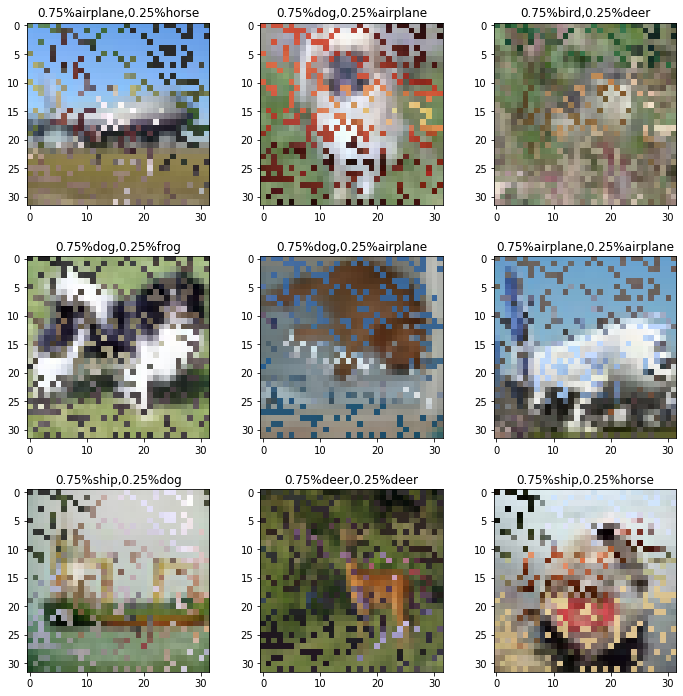

In [6]:
USE_CUDA = True
device = torch.device('cuda' if USE_CUDA else 'cpu')

pr = .75

for batch_id, (images, labels) in enumerate(trainloader):
    if batch_id == 0:
        X_graft, ys, perms = pixelgraft_data(images.to(device), labels.to(device), pr, device)
        break
    

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
plt.tight_layout(pad=2)
for j in range(3):
    for i in range(3):
        utils.show_np_arr(X_graft.cpu()[j*3+i], ax=axes[j, i])
        axes[j, i].set_title(str(pr)[:4] + "%" + trainset.classes[ys[0][j*3+i]] + "," +
                          str(1-pr)[:4] + "%" + trainset.classes[ys[1][j*3+i]], rotation=0)

In [7]:

USE_CUDA = True
N_EPOCHS = 100
N_BATCHES = None
LR = 0.001

#model_getter = lambda: exp_models.resnet18(n=100)
model_getter = exp_models.resnet18

def perform_experiment(prs):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in prs}
    val_losses = {str(k):[] for k in prs}
    
    for pr in prs:
        print_("Trying pr=", pr) 

        device = torch.device('cuda' if USE_CUDA else 'cpu')
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()
        
        pr_rs_tensor = torch.Tensor([pr, 1-pr]).reshape((2, 1, 1, 1, 1)).to(device)

        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            # Training on all batches
            print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
            for batch_id, (images, labels) in enumerate(trainloader):
                if N_BATCHES and batch_id > N_BATCHES:
                    break
                labels, images = labels.to(device), images.to(device)
                images_mx, ys, perms = pixelgraft_data(images, labels, pr, device)
                outputs = model(images_mx)
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, pr_rs_tensor)
                loss_value = loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_losses[str(pr)].append(loss_value)
                if batch_id % 50 == 0:
                    print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    
            # Validating on one batch
            for images, labels in testloader:
                correct = 0
                total = 0
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                val_acc = 100 * correct / total
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, pr_rs_tensor)
                loss_value = loss.item()

                print_('val loss:{:.4f} Epoch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS))
                print_('val acc:{:.4f} Epoch[{}/{}]'.format(
                        val_acc, epoch, N_EPOCHS))
                val_losses[str(pr)].append(loss_value)
                break

        # Test mode
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            # Output test accuracy
            test_acc = 100 * correct / total
            print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
            test_accs[str(pr)] = test_acc


        del device, model, optimizer, criterion
    return test_accs, train_losses, images_mx, ys


In [8]:

for i in range(2):
    PRS = [.875, .625]
    RESULTS_FNAME = "r_cf10_rn18_graft_ss&mo_fill"+str(i)

    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, images_mx, ys = perform_experiment(PRS)

#print(RESULTS_FNAME, PRS)

saving results in r_cf10_rn18_graft_ss&mo_fill0
Trying pr= 0.875
Epoch[1/100]
train loss:2.3621 Epoch[1/100] Batch[0/500]
train loss:1.9066 Epoch[1/100] Batch[50/500]
train loss:1.7661 Epoch[1/100] Batch[100/500]
train loss:1.7354 Epoch[1/100] Batch[150/500]
train loss:1.8518 Epoch[1/100] Batch[200/500]
train loss:1.7837 Epoch[1/100] Batch[250/500]
train loss:1.6516 Epoch[1/100] Batch[300/500]
train loss:1.5611 Epoch[1/100] Batch[350/500]
train loss:1.6983 Epoch[1/100] Batch[400/500]
train loss:1.5809 Epoch[1/100] Batch[450/500]
val loss:3.1351 Epoch[1/100]
val acc:55.0000 Epoch[1/100]
Epoch[2/100]
train loss:1.4913 Epoch[2/100] Batch[0/500]
train loss:1.3500 Epoch[2/100] Batch[50/500]
train loss:1.4869 Epoch[2/100] Batch[100/500]
train loss:1.5020 Epoch[2/100] Batch[150/500]
train loss:1.3583 Epoch[2/100] Batch[200/500]
train loss:1.3349 Epoch[2/100] Batch[250/500]
train loss:1.4889 Epoch[2/100] Batch[300/500]
train loss:1.5629 Epoch[2/100] Batch[350/500]
train loss:1.4426 Epoch[2/100

train loss:0.6178 Epoch[16/100] Batch[150/500]
train loss:0.6290 Epoch[16/100] Batch[200/500]
train loss:0.6211 Epoch[16/100] Batch[250/500]
train loss:0.7090 Epoch[16/100] Batch[300/500]
train loss:0.6822 Epoch[16/100] Batch[350/500]
train loss:0.6449 Epoch[16/100] Batch[400/500]
train loss:0.5885 Epoch[16/100] Batch[450/500]
val loss:4.1896 Epoch[16/100]
val acc:84.0000 Epoch[16/100]
Epoch[17/100]
train loss:0.6326 Epoch[17/100] Batch[0/500]
train loss:0.6468 Epoch[17/100] Batch[50/500]
train loss:0.5882 Epoch[17/100] Batch[100/500]
train loss:0.6740 Epoch[17/100] Batch[150/500]
train loss:0.6276 Epoch[17/100] Batch[200/500]
train loss:0.6165 Epoch[17/100] Batch[250/500]
train loss:0.6579 Epoch[17/100] Batch[300/500]
train loss:0.6137 Epoch[17/100] Batch[350/500]
train loss:0.5954 Epoch[17/100] Batch[400/500]
train loss:0.6724 Epoch[17/100] Batch[450/500]
val loss:3.9359 Epoch[17/100]
val acc:88.0000 Epoch[17/100]
Epoch[18/100]
train loss:0.6307 Epoch[18/100] Batch[0/500]
train loss:

train loss:0.6223 Epoch[31/100] Batch[250/500]
train loss:0.5237 Epoch[31/100] Batch[300/500]
train loss:0.5588 Epoch[31/100] Batch[350/500]
train loss:0.6002 Epoch[31/100] Batch[400/500]
train loss:0.5525 Epoch[31/100] Batch[450/500]
val loss:4.1509 Epoch[31/100]
val acc:84.0000 Epoch[31/100]
Epoch[32/100]
train loss:0.6097 Epoch[32/100] Batch[0/500]
train loss:0.5878 Epoch[32/100] Batch[50/500]
train loss:0.5864 Epoch[32/100] Batch[100/500]
train loss:0.5659 Epoch[32/100] Batch[150/500]
train loss:0.5750 Epoch[32/100] Batch[200/500]
train loss:0.5976 Epoch[32/100] Batch[250/500]
train loss:0.6232 Epoch[32/100] Batch[300/500]
train loss:0.6031 Epoch[32/100] Batch[350/500]
train loss:0.5577 Epoch[32/100] Batch[400/500]
train loss:0.5860 Epoch[32/100] Batch[450/500]
val loss:4.5230 Epoch[32/100]
val acc:85.0000 Epoch[32/100]
Epoch[33/100]
train loss:0.5698 Epoch[33/100] Batch[0/500]
train loss:0.5697 Epoch[33/100] Batch[50/500]
train loss:0.6050 Epoch[33/100] Batch[100/500]
train loss:0

train loss:0.5799 Epoch[46/100] Batch[350/500]
train loss:0.5855 Epoch[46/100] Batch[400/500]
train loss:0.5299 Epoch[46/100] Batch[450/500]
val loss:4.5601 Epoch[46/100]
val acc:83.0000 Epoch[46/100]
Epoch[47/100]
train loss:0.5696 Epoch[47/100] Batch[0/500]
train loss:0.5457 Epoch[47/100] Batch[50/500]
train loss:0.5358 Epoch[47/100] Batch[100/500]
train loss:0.5624 Epoch[47/100] Batch[150/500]
train loss:0.5357 Epoch[47/100] Batch[200/500]
train loss:0.5088 Epoch[47/100] Batch[250/500]
train loss:0.5775 Epoch[47/100] Batch[300/500]
train loss:0.5490 Epoch[47/100] Batch[350/500]
train loss:0.5648 Epoch[47/100] Batch[400/500]
train loss:0.6032 Epoch[47/100] Batch[450/500]
val loss:4.3618 Epoch[47/100]
val acc:85.0000 Epoch[47/100]
Epoch[48/100]
train loss:0.5161 Epoch[48/100] Batch[0/500]
train loss:0.5663 Epoch[48/100] Batch[50/500]
train loss:0.5430 Epoch[48/100] Batch[100/500]
train loss:0.5688 Epoch[48/100] Batch[150/500]
train loss:0.5389 Epoch[48/100] Batch[200/500]
train loss:0

train loss:0.5506 Epoch[61/100] Batch[450/500]
val loss:4.2830 Epoch[61/100]
val acc:89.0000 Epoch[61/100]
Epoch[62/100]
train loss:0.5646 Epoch[62/100] Batch[0/500]
train loss:0.5296 Epoch[62/100] Batch[50/500]
train loss:0.5104 Epoch[62/100] Batch[100/500]
train loss:0.5258 Epoch[62/100] Batch[150/500]
train loss:0.5315 Epoch[62/100] Batch[200/500]
train loss:0.5433 Epoch[62/100] Batch[250/500]
train loss:0.5514 Epoch[62/100] Batch[300/500]
train loss:0.5560 Epoch[62/100] Batch[350/500]
train loss:0.5192 Epoch[62/100] Batch[400/500]
train loss:0.5224 Epoch[62/100] Batch[450/500]
val loss:4.4777 Epoch[62/100]
val acc:87.0000 Epoch[62/100]
Epoch[63/100]
train loss:0.5466 Epoch[63/100] Batch[0/500]
train loss:0.5524 Epoch[63/100] Batch[50/500]
train loss:0.5224 Epoch[63/100] Batch[100/500]
train loss:0.5254 Epoch[63/100] Batch[150/500]
train loss:0.5372 Epoch[63/100] Batch[200/500]
train loss:0.4852 Epoch[63/100] Batch[250/500]
train loss:0.4940 Epoch[63/100] Batch[300/500]
train loss:0

...

train loss:1.1323 Epoch[35/100] Batch[100/500]
train loss:1.1105 Epoch[35/100] Batch[150/500]
train loss:1.2171 Epoch[35/100] Batch[200/500]
train loss:1.1380 Epoch[35/100] Batch[250/500]
train loss:1.0628 Epoch[35/100] Batch[300/500]
train loss:1.0021 Epoch[35/100] Batch[350/500]
train loss:1.1762 Epoch[35/100] Batch[400/500]
train loss:1.3424 Epoch[35/100] Batch[450/500]
val loss:4.4003 Epoch[35/100]
val acc:84.0000 Epoch[35/100]
Epoch[36/100]
train loss:1.1601 Epoch[36/100] Batch[0/500]
train loss:1.0796 Epoch[36/100] Batch[50/500]
train loss:0.9784 Epoch[36/100] Batch[100/500]
train loss:1.1457 Epoch[36/100] Batch[150/500]
train loss:1.2130 Epoch[36/100] Batch[200/500]
train loss:1.1433 Epoch[36/100] Batch[250/500]
train loss:1.2344 Epoch[36/100] Batch[300/500]
train loss:1.1077 Epoch[36/100] Batch[350/500]
train loss:1.2083 Epoch[36/100] Batch[400/500]
train loss:1.1355 Epoch[36/100] Batch[450/500]
val loss:4.4432 Epoch[36/100]
val acc:88.0000 Epoch[36/100]
Epoch[37/100]
train los

train loss:1.0685 Epoch[50/100] Batch[200/500]
train loss:1.1298 Epoch[50/100] Batch[250/500]
train loss:0.9661 Epoch[50/100] Batch[300/500]
train loss:0.9682 Epoch[50/100] Batch[350/500]
train loss:1.0039 Epoch[50/100] Batch[400/500]
train loss:1.1007 Epoch[50/100] Batch[450/500]
val loss:5.0485 Epoch[50/100]
val acc:86.0000 Epoch[50/100]
Epoch[51/100]
train loss:1.0333 Epoch[51/100] Batch[0/500]
train loss:1.0025 Epoch[51/100] Batch[50/500]
train loss:1.0645 Epoch[51/100] Batch[100/500]
train loss:0.9377 Epoch[51/100] Batch[150/500]
train loss:1.1493 Epoch[51/100] Batch[200/500]
train loss:1.0590 Epoch[51/100] Batch[250/500]
train loss:1.0368 Epoch[51/100] Batch[300/500]
train loss:0.9704 Epoch[51/100] Batch[350/500]
train loss:1.1313 Epoch[51/100] Batch[400/500]
train loss:1.1242 Epoch[51/100] Batch[450/500]
val loss:5.1476 Epoch[51/100]
val acc:87.0000 Epoch[51/100]
Epoch[52/100]
train loss:1.0507 Epoch[52/100] Batch[0/500]
train loss:1.0146 Epoch[52/100] Batch[50/500]
train loss:0

train loss:0.9025 Epoch[65/100] Batch[300/500]
train loss:0.9299 Epoch[65/100] Batch[350/500]
train loss:0.8957 Epoch[65/100] Batch[400/500]
train loss:0.9285 Epoch[65/100] Batch[450/500]
val loss:5.2606 Epoch[65/100]
val acc:90.0000 Epoch[65/100]
Epoch[66/100]
train loss:0.9142 Epoch[66/100] Batch[0/500]
train loss:0.8940 Epoch[66/100] Batch[50/500]
train loss:0.9889 Epoch[66/100] Batch[100/500]
train loss:1.1947 Epoch[66/100] Batch[150/500]
train loss:1.0081 Epoch[66/100] Batch[200/500]
train loss:0.8973 Epoch[66/100] Batch[250/500]
train loss:0.9434 Epoch[66/100] Batch[300/500]
train loss:0.9110 Epoch[66/100] Batch[350/500]
train loss:0.9360 Epoch[66/100] Batch[400/500]
train loss:0.9948 Epoch[66/100] Batch[450/500]
val loss:5.2236 Epoch[66/100]
val acc:88.0000 Epoch[66/100]
Epoch[67/100]
train loss:0.9611 Epoch[67/100] Batch[0/500]
train loss:1.0248 Epoch[67/100] Batch[50/500]
train loss:0.9662 Epoch[67/100] Batch[100/500]
train loss:0.9264 Epoch[67/100] Batch[150/500]
train loss:0

train loss:0.9192 Epoch[80/100] Batch[400/500]
train loss:0.9079 Epoch[80/100] Batch[450/500]
val loss:5.6989 Epoch[80/100]
val acc:87.0000 Epoch[80/100]
Epoch[81/100]
train loss:0.8413 Epoch[81/100] Batch[0/500]
train loss:0.9147 Epoch[81/100] Batch[50/500]
train loss:0.8870 Epoch[81/100] Batch[100/500]
train loss:0.8401 Epoch[81/100] Batch[150/500]
train loss:0.8547 Epoch[81/100] Batch[200/500]
train loss:0.9542 Epoch[81/100] Batch[250/500]
train loss:0.8757 Epoch[81/100] Batch[300/500]
train loss:0.9855 Epoch[81/100] Batch[350/500]
train loss:0.9276 Epoch[81/100] Batch[400/500]
train loss:0.9815 Epoch[81/100] Batch[450/500]
val loss:5.7099 Epoch[81/100]
val acc:86.0000 Epoch[81/100]
Epoch[82/100]
train loss:0.8886 Epoch[82/100] Batch[0/500]
train loss:0.9124 Epoch[82/100] Batch[50/500]
train loss:0.8769 Epoch[82/100] Batch[100/500]
train loss:0.9061 Epoch[82/100] Batch[150/500]
train loss:0.8877 Epoch[82/100] Batch[200/500]
train loss:0.8429 Epoch[82/100] Batch[250/500]
train loss:0

val loss:5.8528 Epoch[95/100]
val acc:88.0000 Epoch[95/100]
Epoch[96/100]
train loss:0.8767 Epoch[96/100] Batch[0/500]
train loss:0.8453 Epoch[96/100] Batch[50/500]
train loss:0.8474 Epoch[96/100] Batch[100/500]
train loss:0.8464 Epoch[96/100] Batch[150/500]
train loss:0.8381 Epoch[96/100] Batch[200/500]
train loss:0.8096 Epoch[96/100] Batch[250/500]
train loss:0.8457 Epoch[96/100] Batch[300/500]
train loss:0.8455 Epoch[96/100] Batch[350/500]
train loss:0.8065 Epoch[96/100] Batch[400/500]
train loss:0.9421 Epoch[96/100] Batch[450/500]
val loss:6.1311 Epoch[96/100]
val acc:86.0000 Epoch[96/100]
Epoch[97/100]
train loss:0.8121 Epoch[97/100] Batch[0/500]
train loss:0.8220 Epoch[97/100] Batch[50/500]
train loss:0.8735 Epoch[97/100] Batch[100/500]
train loss:0.8266 Epoch[97/100] Batch[150/500]
train loss:0.9076 Epoch[97/100] Batch[200/500]
train loss:0.9250 Epoch[97/100] Batch[250/500]
train loss:0.9430 Epoch[97/100] Batch[300/500]
train loss:0.7813 Epoch[97/100] Batch[350/500]
train loss:0

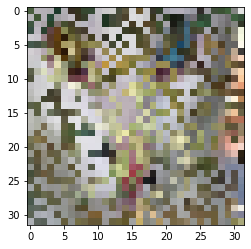

In [9]:


utils.show_np_arr(images_mx.cpu()[0])